In [1]:
import geopandas as gpd
import pandas as pd
import leafmap
from ipyleaflet import Icon


df = pd.read_csv("https://docs.google.com/spreadsheets/d/1_m2smpUBVC3jqBvn3fyskRCJyRYVAzdIjmU-8UWMQ20/export?format=csv&pli=1&gid=1865447611#gid=1865447611")
df['Latitude'] = df['Latitude'].apply(lambda x: float(x.replace(',', '.')))
df['Longitude'] = df['Longitude'].apply(lambda x: float(x.replace(',', '.')))   

# Definisci le icone per interno ed esterno
icon_dict = {
    "Spazi interni": "https://cdn.jsdelivr.net/gh/pointhi/leaflet-color-markers@master/img/marker-icon-red.png",
    "Spazi esterni": "https://cdn.jsdelivr.net/gh/pointhi/leaflet-color-markers@master/img/marker-icon-green.png"
}

# Crea una colonna 'icon' in base alla colonna 'legenda'
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']))
gdf.crs = "EPSG:4326"
gdf.to_file("rifugi_climatici.geojson", driver='GeoJSON')


In [ ]:
gdf["icon"] = gdf["legenda"].map(icon_dict)


m = leafmap.Map(center=[45.0, 10.0], zoom=6)

import ipywidgets as widgets

for _, row in gdf.iterrows():

    icon = Icon(icon_url=row["icon"], icon_size=[25, 41], icon_anchor=[12, 41])
    popup_widget = widgets.HTML(value=row["nome"])
    m.add_marker(
        location=[row["Latitude"], row["Longitude"]],
        icon=icon,
        popup=popup_widget,
        draggable=False,
        title=row["nome"]
    )

m.add_gdf(gdf, layer_name="Rifugi Climatici")
m

# Rifugi Climatici Plus

In [1]:
import geopandas as gpd
import pandas as pd
import leafmap
aree_permeabili = gpd.read_file("aree_verdi_AP2025.json")

aree_permeabili = aree_permeabili.to_crs("EPSG:32633")
#calcola l'area in metri quadrati
aree_permeabili["area_verde_mq"] = aree_permeabili.geometry.area

# seleziona  'verde stradale', 'parco municipale', 'parco centrale','parchi pubblici non comunali', 'fonte arborea','aiuola municipale',
aree_permeabili = aree_permeabili[aree_permeabili["DESCRIPTIO"].isin([
    'verde stradale', 'parco municipale', 'parco centrale',
    'parchi pubblici non comunali', 'fonte arborea',
])]

# crea dizionario per mappare le muinicipalità con i numeri da 1 a 10 a partire dai valori di MUN "nona municipalita'", "sesta municipalita'", 'quinta municipalita', etc..
 
aree_permeabili['MUN_CODE'] = aree_permeabili['MUN'].map({
    "nona municipalita'": 9,
    "sesta municipalita'": 6,
    "quinta municipalita": 5,
    "quarta municipalita'": 4,
    "terza municipalita'": 3,
    "seconda municipalita'": 2,
    "prima municipalita'": 1,
    "decima municipalita'": 10,
    "settima municipalita'": 7,
    "ottava municipalita'": 8
    })

# Rimuovi le righe con MUN_CODE mancante prima di convertire in int
aree_permeabili = aree_permeabili.dropna(subset=['MUN_CODE'])
aree_permeabili['MUN_CODE'] = aree_permeabili['MUN_CODE'].astype(int)
municipalita = gpd.read_file("municipalita.geojson")
municipalita['MUN_CODE']= municipalita['municip'].map({
    'Municipalita 1': 1,
    'Municipalita 2': 2,
    'Municipalita 3': 3,
    'Municipalita 4': 4,
    'Municipalita 5': 5,
    'Municipalita 6': 6,
    'Municipalita 7': 7,
    'Municipalita 8': 8,
    'Municipalita 9': 9,
    'Municipalita 10': 10
})
municipalita = municipalita.to_crs("EPSG:32633")
municipalita["area_municipalita_mq"] = municipalita.geometry.area
#municipalita = municipalita[["MUN_CODE", "area_municipalita_mq"]]
aree_permeabili = aree_permeabili.merge(municipalita, on="MUN_CODE", suffixes=("", "_municipalita"))

municipalita = municipalita.set_index("MUN_CODE")
# calcola la percentuale di area verde totale per ogni municipalità
municipalita["percentuale_area_verde_ap"] = (
    aree_permeabili.groupby("MUN_CODE")["area_verde_mq"].sum() / municipalita["area_municipalita_mq"]
) * 100
municipalita['percentuale_area_verde_ap'] = round(municipalita['percentuale_area_verde_ap'], 1)
municipalita

,osm_id,municip,geometry,area_municipalita_mq,percentuale_area_verde_ap
MUN_CODE,,,,,
1,6288409,Municipalita 1,"MULTIPOLYGON (((431404.207 4515964.626, 431407...",9.045759e+06,2.2
2,6288446,Municipalita 2,"MULTIPOLYGON (((437387.258 4521160.064, 437395...",4.195453e+06,1.3
3,6288473,Municipalita 3,"MULTIPOLYGON (((435331.269 4523596.507, 435350...",9.633569e+06,15.6
10,6548749,Municipalita 10,"MULTIPOLYGON (((429139.912 4516196.8, 429155.1...",1.446168e+07,0.5
4,6548750,Municipalita 4,"MULTIPOLYGON (((438851.213 4521743.718, 438858...",9.693819e+06,0.7
5,6548751,Municipalita 5,"MULTIPOLYGON (((434508.157 4524452.891, 434508...",7.307896e+06,1.9
6,6548752,Municipalita 6,"MULTIPOLYGON (((443199.502 4525685.478, 443432...",1.985037e+07,1.4
7,6548753,Municipalita 7,"MULTIPOLYGON (((436650.129 4526067.111, 436632...",1.031634e+07,1.0
8,6548754,Municipalita 8,"MULTIPOLYGON (((431608.684 4524054.574, 431585...",1.752285e+07,1.1


### Visualizza Percentuale di area verde per municipalità [Aree Permeabili]

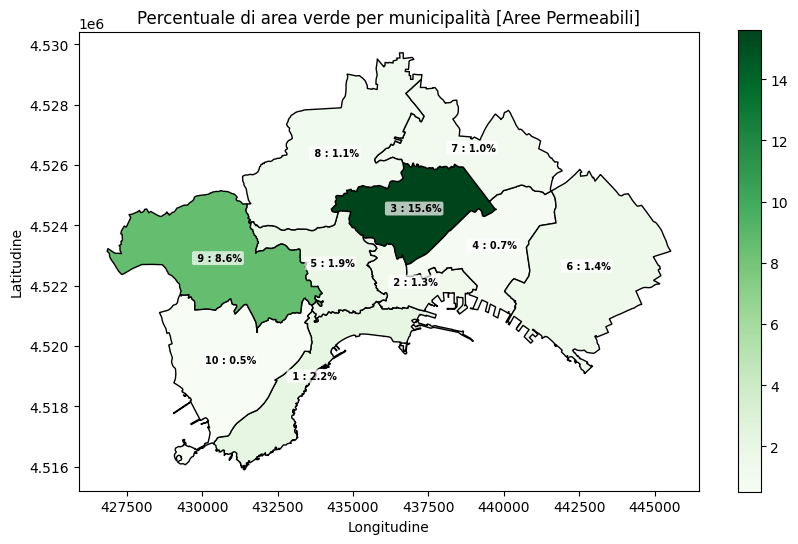

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
municipalita.plot(
    column="percentuale_area_verde_ap",
    cmap="Greens",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=1
)

for idx, row in municipalita.iterrows():
    # Prendi il centroide della geometria per posizionare l'etichetta
    centroid = row.geometry.centroid
    ax.annotate(
        text=str(row['municip'][-2:])+" : "+str(row['percentuale_area_verde_ap'])+"%",  # idx è il MUN_CODE
        xy=(centroid.x, centroid.y),
        ha='center',
        va='center',
        fontsize=7,
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2')
    )

plt.title("Percentuale di area verde per municipalità [Aree Permeabili]")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.show()

### Add Land cover

In [3]:


# Carica Landcover
land_cover = gpd.read_file('output_LandCover_ESRI.geojson')  # Sostituisci con il nome del secondo file GeoJSON
land_cover = land_cover[land_cover["classification"].isin([
    'Trees', 
])]

# sjoin tra land_cover e municipalita
# Assicurati che entrambi i GeoDataFrame siano nello stesso CRS
land_cover = land_cover.to_crs(municipalita.crs)
municipalita = municipalita.to_crs(land_cover.crs)
# Esegui lo spatial join
land_cover_sjoin = gpd.sjoin(land_cover, municipalita, how="left", predicate="intersects")  
# prendi i land_cover che hanno un MUN_CODE associato
land_cover_sjoin = land_cover_sjoin[land_cover_sjoin['MUN_CODE'].notna()]
land_cover_sjoin['MUN_CODE'] = land_cover_sjoin['MUN_CODE'].astype(int)

# Combina i GeoDataFrame
lc_ap = gpd.GeoDataFrame(pd.concat([aree_permeabili, land_cover_sjoin], ignore_index=True), crs=aree_permeabili.crs)
lc_ap['DESCRIPTIO'] = lc_ap['DESCRIPTIO'].combine_first(lc_ap['classification'])

# calcola l'area in metri quadrati
lc_ap["area_lc_ap_mq"] = lc_ap.geometry.area

# calcola la percentuale di area verde totale per ogni municipalità
municipalita["percentuale_area_lc_ap_verde"] = (
    lc_ap.groupby("MUN_CODE")["area_lc_ap_mq"].sum() / municipalita["area_municipalita_mq"]
) * 100

municipalita["percentuale_area_lc_ap_verde"] = round(municipalita["percentuale_area_lc_ap_verde"], 1)
municipalita


,osm_id,municip,geometry,area_municipalita_mq,percentuale_area_verde_ap,percentuale_area_lc_ap_verde
MUN_CODE,,,,,,
1,6288409,Municipalita 1,"MULTIPOLYGON (((431404.207 4515964.626, 431407...",9.045759e+06,2.2,4.6
2,6288446,Municipalita 2,"MULTIPOLYGON (((437387.258 4521160.064, 437395...",4.195453e+06,1.3,1.3
3,6288473,Municipalita 3,"MULTIPOLYGON (((435331.269 4523596.507, 435350...",9.633569e+06,15.6,31.3
10,6548749,Municipalita 10,"MULTIPOLYGON (((429139.912 4516196.8, 429155.1...",1.446168e+07,0.5,23.0
4,6548750,Municipalita 4,"MULTIPOLYGON (((438851.213 4521743.718, 438858...",9.693819e+06,0.7,0.7
5,6548751,Municipalita 5,"MULTIPOLYGON (((434508.157 4524452.891, 434508...",7.307896e+06,1.9,28.0
6,6548752,Municipalita 6,"MULTIPOLYGON (((443199.502 4525685.478, 443432...",1.985037e+07,1.4,2.3
7,6548753,Municipalita 7,"MULTIPOLYGON (((436650.129 4526067.111, 436632...",1.031634e+07,1.0,13.1
8,6548754,Municipalita 8,"MULTIPOLYGON (((431608.684 4524054.574, 431585...",1.752285e+07,1.1,14.6


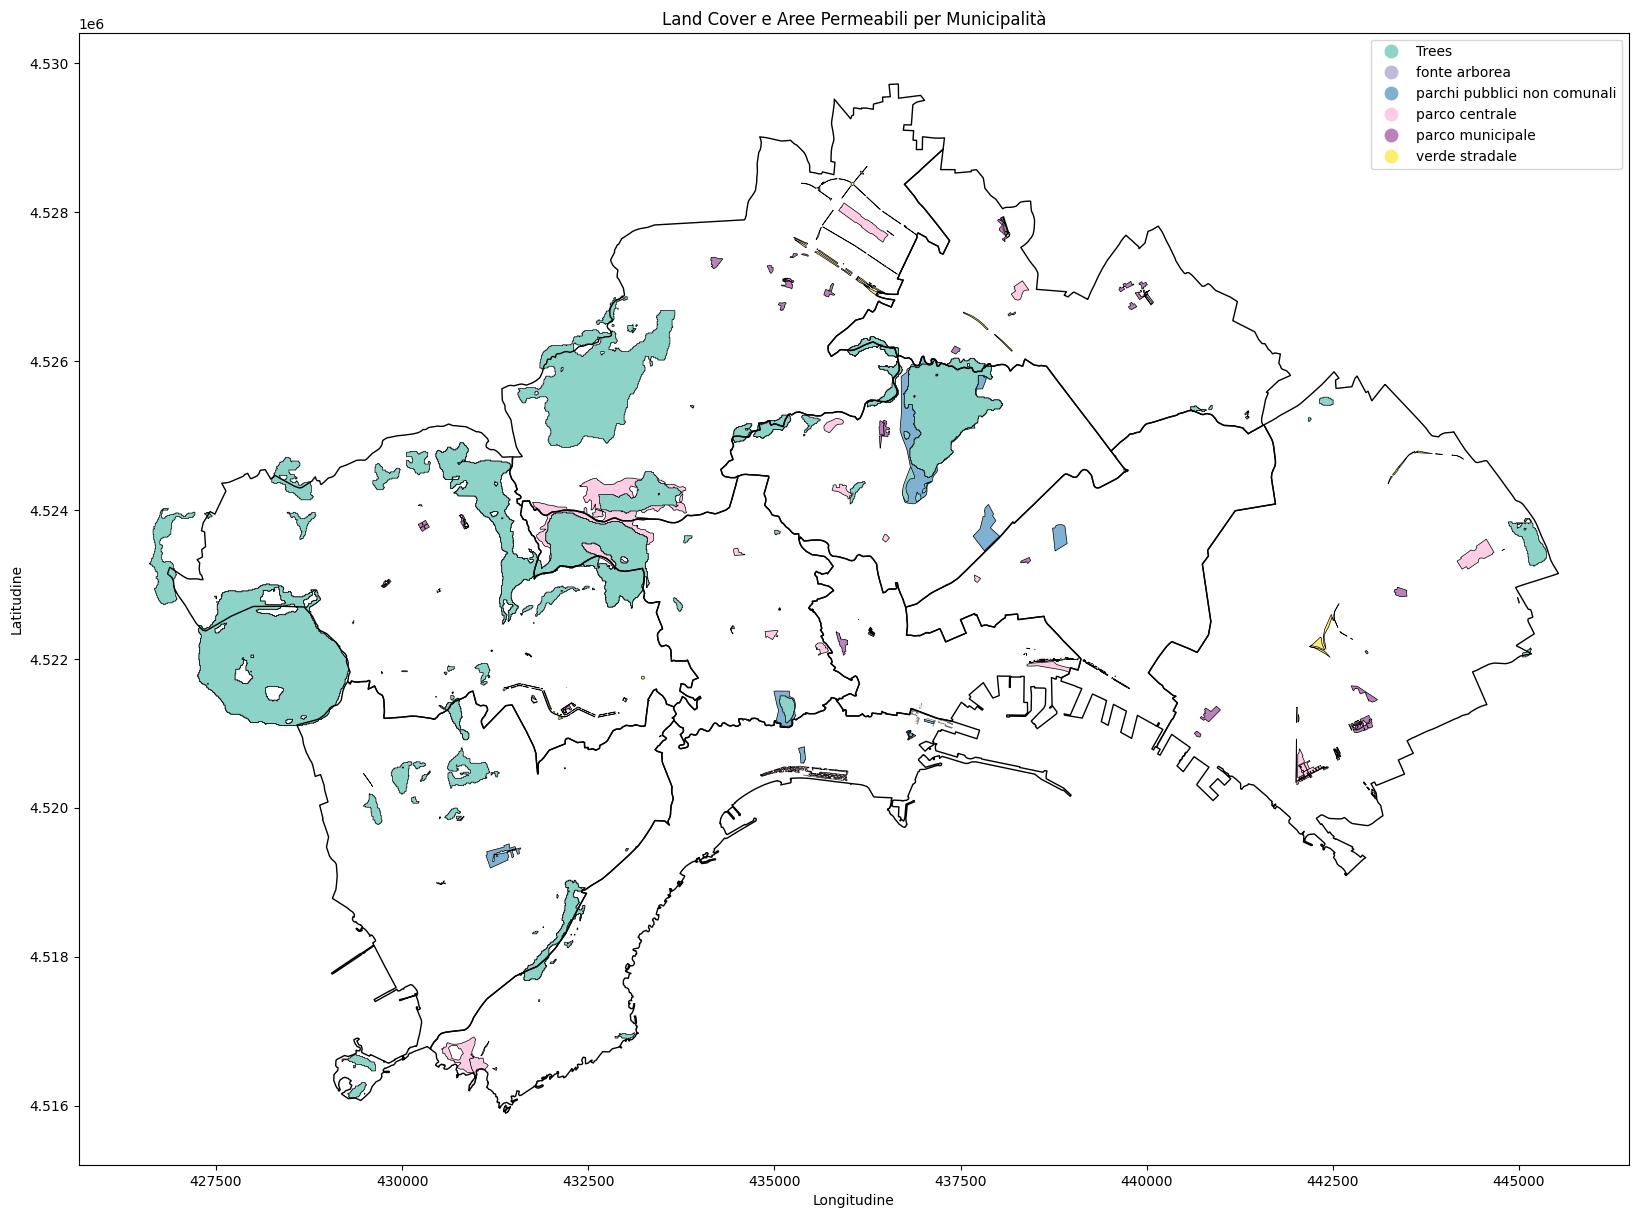

In [4]:
# visualizza layer lc_ap e municipalita con matplotlib
fig, ax = plt.subplots(figsize=(20, 15))
lc_ap.plot(
    column="DESCRIPTIO",
    cmap="Set3",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)
municipalita.boundary.plot(ax=ax, color='black', linewidth=1)          
plt.title("Land Cover e Aree Permeabili per Municipalità")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.show()

In [5]:
# AGGIUNGI ToTALE MQ AREA VERDE A MUNICIPALITA
municipalita = municipalita.merge(lc_ap.groupby("MUN_CODE")["area_lc_ap_mq"].sum().reset_index(), on="MUN_CODE", how="left")
municipalita

,MUN_CODE,osm_id,municip,geometry,area_municipalita_mq,percentuale_area_verde_ap,percentuale_area_lc_ap_verde,area_lc_ap_mq
0,1,6288409,Municipalita 1,"MULTIPOLYGON (((431404.207 4515964.626, 431407...",9.045759e+06,2.2,4.6,4.125547e+05
1,2,6288446,Municipalita 2,"MULTIPOLYGON (((437387.258 4521160.064, 437395...",4.195453e+06,1.3,1.3,5.651897e+04
2,3,6288473,Municipalita 3,"MULTIPOLYGON (((435331.269 4523596.507, 435350...",9.633569e+06,15.6,31.3,3.018903e+06
3,10,6548749,Municipalita 10,"MULTIPOLYGON (((429139.912 4516196.8, 429155.1...",1.446168e+07,0.5,23.0,3.319473e+06
4,4,6548750,Municipalita 4,"MULTIPOLYGON (((438851.213 4521743.718, 438858...",9.693819e+06,0.7,0.7,7.187006e+04
5,5,6548751,Municipalita 5,"MULTIPOLYGON (((434508.157 4524452.891, 434508...",7.307896e+06,1.9,28.0,2.042564e+06
6,6,6548752,Municipalita 6,"MULTIPOLYGON (((443199.502 4525685.478, 443432...",1.985037e+07,1.4,2.3,4.480393e+05
7,7,6548753,Municipalita 7,"MULTIPOLYGON (((436650.129 4526067.111, 436632...",1.031634e+07,1.0,13.1,1.349658e+06
8,8,6548754,Municipalita 8,"MULTIPOLYGON (((431608.684 4524054.574, 431585...",1.752285e+07,1.1,14.6,2.551292e+06
9,9,6548755,Municipalita 9,"MULTIPOLYGON (((429267.965 4521693.991, 429273...",1.646740e+07,8.6,40.2,6.618127e+06


# Popolazione 2016

In [1]:
import pandas as pd

# Dati in formato lista di dizionari
data = [
    {"MUN_CODE": 1, "popolazione_2016": 79616, "densita_abitativa_ab_m2": 9047.272727},
    {"MUN_CODE": 2, "popolazione_2016": 92272, "densita_abitativa_ab_m2": 20235.08772},
    {"MUN_CODE": 3, "popolazione_2016": 99577, "densita_abitativa_ab_m2": 10470.76761},
    {"MUN_CODE": 4, "popolazione_2016": 93035, "densita_abitativa_ab_m2": 10036.13808},
    {"MUN_CODE": 5, "popolazione_2016": 112425, "densita_abitativa_ab_m2": 15151.61725},
    {"MUN_CODE": 6, "popolazione_2016": 112765, "densita_abitativa_ab_m2": 5848.807054},
    {"MUN_CODE": 7, "popolazione_2016": 84047, "densita_abitativa_ab_m2": 8191.7154},
    {"MUN_CODE": 8, "popolazione_2016": 89990, "densita_abitativa_ab_m2": 5157.020057},
    {"MUN_CODE": 9, "popolazione_2016": 103135, "densita_abitativa_ab_m2": 6227.958937},
    {"MUN_CODE": 10, "popolazione_2016": 95141, "densita_abitativa_ab_m2": 6718.997175}
]

# Converti in DataFrame
popolazione = pd.DataFrame(data)


# somma tutta la popolazione da 'Pop_municipi'
popolazione_totale = popolazione["popolazione_2016"].sum()
print(f"Popolazione totale a Napoli nel 2016: {popolazione_totale}")
#merge con municipalita
municipalita = municipalita.merge(popolazione, on="MUN_CODE", how="left")



# Calcola mq di area verde totale per abitante per ogni municipalità

municipalita["mq_area_verde_per_abitante"] = (
    municipalita["area_lc_ap_mq"] / municipalita["popolazione_2016"]
) * 100

municipalita["densita_abitativa_ab_m2"] = round(municipalita["densita_abitativa_ab_m2"], 1)
municipalita["mq_area_verde_per_abitante"] = round(municipalita["mq_area_verde_per_abitante"], 1)

Popolazione totale a Napoli nel 2016: 962003


NameError: name 'municipalita' is not defined

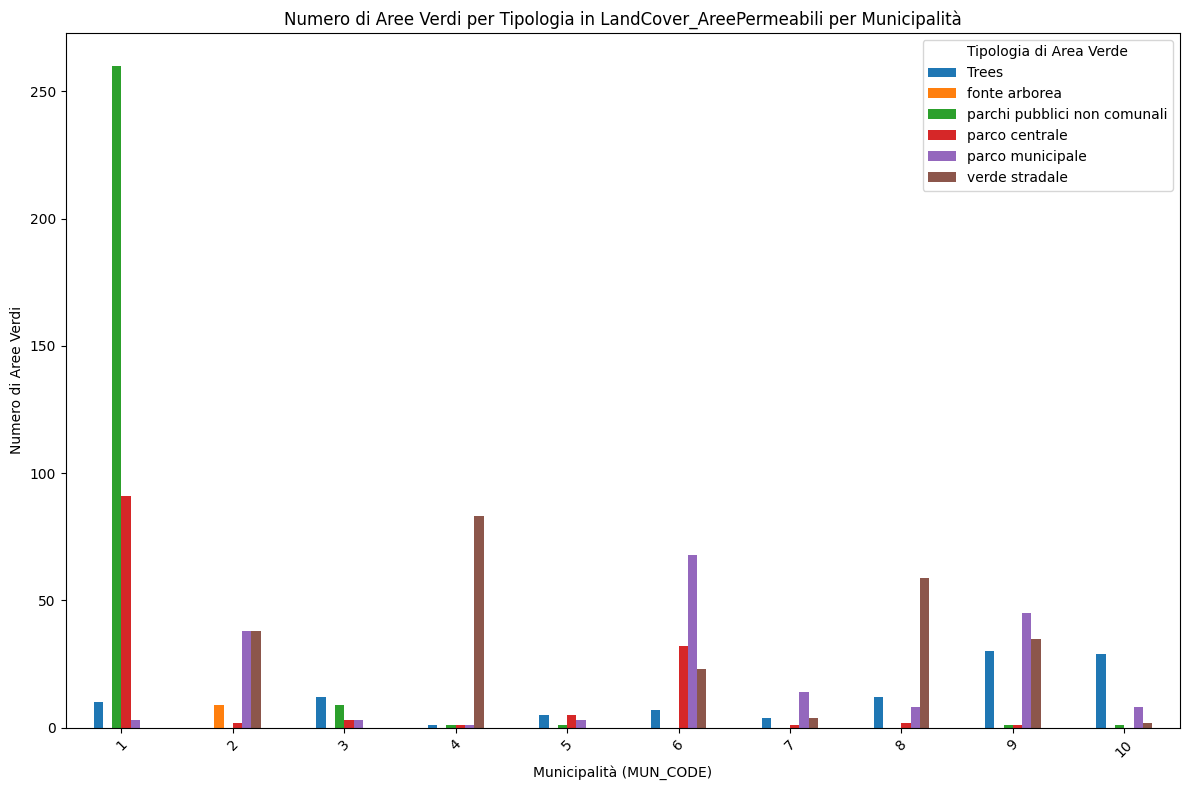

In [ ]:
# conta il numero di aree verdi per tipologi in lc_ap per ogni municipalità
aree_verdi_per_municipalita = lc_ap.groupby(["MUN_CODE", "DESCRIPTIO"]).size().reset_index(name='count')
#Visualizza il numero di aree verdi per tipologia in lc_ap per ogni municipalità, visualizzando un grafico a barre a grupppi
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
aree_verdi_per_municipalita.pivot(index='MUN_CODE', columns='DESCRIPTIO', values='count').plot(kind='bar', ax=ax)
ax.set_title('Numero di Aree Verdi per Tipologia in LandCover_AreePermeabili per Municipalità')
ax.set_xlabel('Municipalità (MUN_CODE)')
ax.set_ylabel('Numero di Aree Verdi')
plt.xticks(rotation=45)
plt.legend(title='Tipologia di Area Verde')
plt.tight_layout()
plt.show()

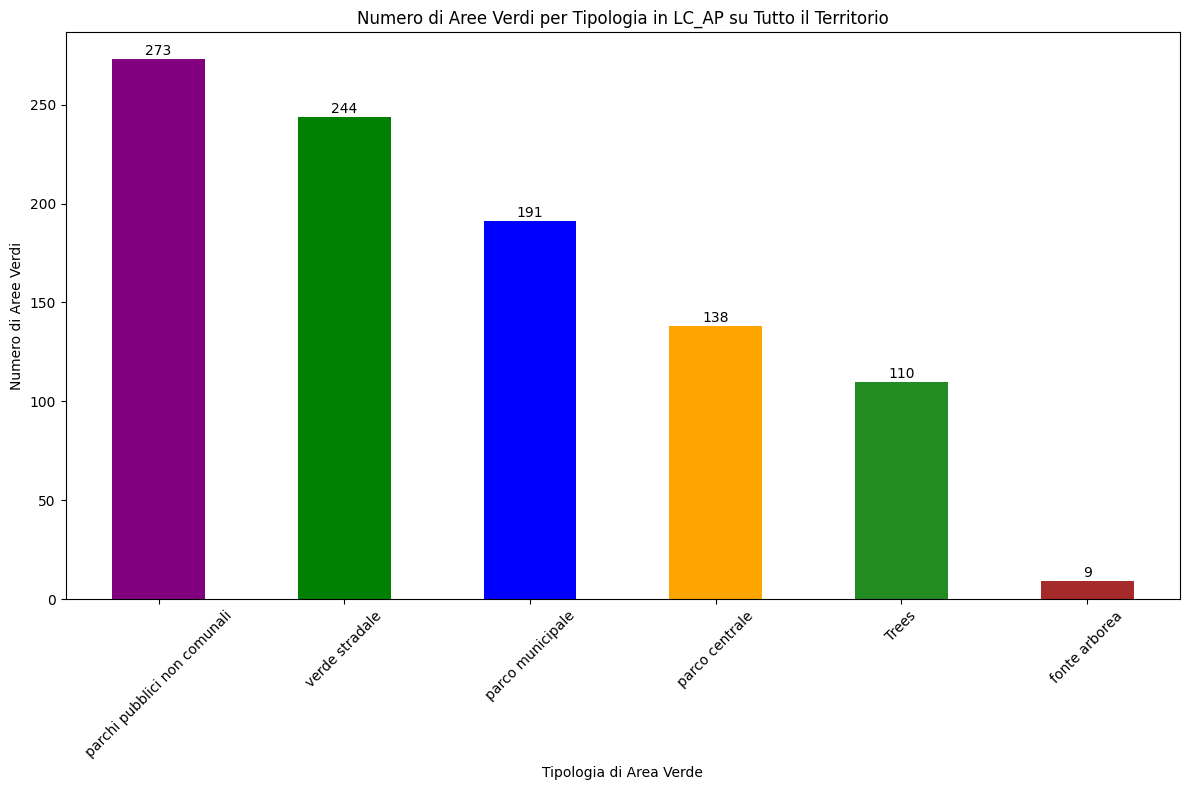

In [ ]:
# visualizza su grafico barra il numero di aree verdi per tipologia in lc_ap su tutto il territorio, colora le barre in base alla tipologia, mettendo un anche il conteggio per tipologia nel grafico
aree_verdi_totali = lc_ap['DESCRIPTIO'].value_counts()
color_map = {
    'verde stradale': 'green',
    'parco municipale': 'blue',
    'parco centrale': 'orange',
    'parchi pubblici non comunali': 'purple',
    'fonte arborea': 'brown',
    'aiuola municipale': 'pink',
    'Trees': 'forestgreen'
}
colors = [color_map.get(tipologia, 'gray') for tipologia in aree_verdi_totali.index]
fig, ax = plt.subplots(figsize=(12, 8))
aree_verdi_totali.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Numero di Aree Verdi per Tipologia in LC_AP su Tutto il Territorio')
ax.set_xlabel('Tipologia di Area Verde')
ax.set_ylabel('Numero di Aree Verdi')
for i, v in enumerate(aree_verdi_totali):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

In [ ]:
municipalita.columns

Index(['MUN_CODE', 'osm_id', 'municip', 'geometry', 'area_municipalita_mq',
       'percentuale_area_verde_ap', 'percentuale_area_lc_ap_verde',
       'area_lc_ap_mq', 'popolazione_2016', 'densita_abitativa_ab_m2',
       'mq_area_verde_per_abitante'],
      dtype='object')

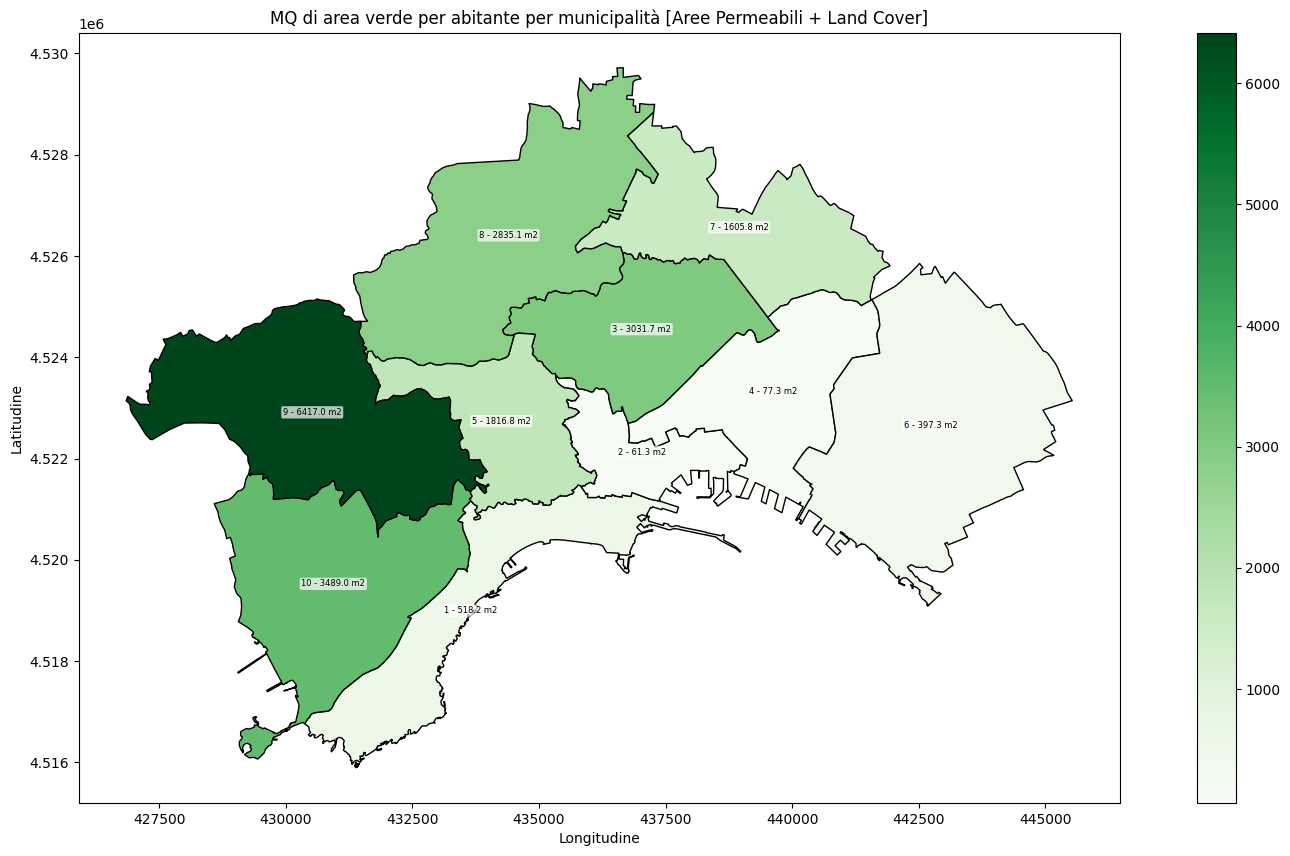

In [ ]:
# plotta municipalita  per area verde per abitante
fig, ax = plt.subplots(figsize=(20, 10))
municipalita.plot(
    column="mq_area_verde_per_abitante",
    cmap="Greens",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=1
)                       
for idx, row in municipalita.iterrows():
    # Prendi il centroide della geometria per posizionare l'etichetta
    centroid = row.geometry.centroid
    ax.annotate(
        text=str(row["MUN_CODE"])+' - '+ str(row["mq_area_verde_per_abitante"])+ ' m2',
        xy=(centroid.x, centroid.y),
        ha='center',
        va='center',
        fontsize=6,
        #fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2')
    )       
plt.title("MQ di area verde per abitante per municipalità [Aree Permeabili + Land Cover]")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.show()

In [ ]:
import folium
municipalita = municipalita.to_crs("EPSG:4326")  # Converti in WGS84 per la visualizzazione su mappa

config_map = {
    'column': 'mq_area_verde_per_abitante',  # Nome della colonna da mappare (deve essere numerica)
    'name':'mq_area_verde_per_abitante',  # Nome del layer
    'cmap': 'Reds',  # Colore della mappa. Possibili valori:
                        # 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 
                        # 'Blues', 'Reds', 'Greens', 'Greys', 'Purples', 
                        # 'Oranges', 'Spectral', 'RdYlBu', etc. #['blue', 'orange']
    'tiles': 'OpenStreetMap', #["OpenStreetMap", "CartoDB positron", “CartoDB dark_matter"] or http://{s}.yourtiles.com/{z}/{x}/{y}.png
    'attr':'CartoDB maps',
    'popup':True,
    'highlight':True,
    'k':5,
    'legend': True,
    'legend_kwds':{'scale':False},  # Mostra la legenda sulla mappa (True o False)
    'colorbar': True,
    'tooltip': True,  # Mostra le informazioni al passaggio del mouse (True o False)
 
}


m = municipalita.explore(**config_map)

folium.LayerControl().add_to(m)
m


In [ ]:
import xarray as xr
remote_product_path = "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:202507-s01siwgrh/28/products/cpm_v256/S1A_IW_GRDH_1SDV_20250728T205936_20250728T210005_060289_077E1C_1474.zarr"
dt = xr.open_datatree(remote_product_path, engine="rasterio", chunks={})


In [ ]:
import xarray as xr
import fsspec
import numpy as np

url = 's3://noaa-nwm-retro-v2-zarr-pds'
ds = xr.open_zarr(fsspec.get_mapper(url, anon=True), consolidated=True)


In [4]:
remote_product_path = "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:202507-s01siwgrh/28/products/cpm_v256/S1A_IW_GRDH_1SDV_20250728T205936_20250728T210005_060289_077E1C_1474.zarr"
ds = xr.open_zarr(remote_product_path, consolidated=True)


In [ ]:
ds.attrs